In [11]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

--- Evaluación del Modelo Normalizado ---
R2-score: 0.9207

El pronóstico del PIB para México en 2022 es: 1,224,376,474,853.13


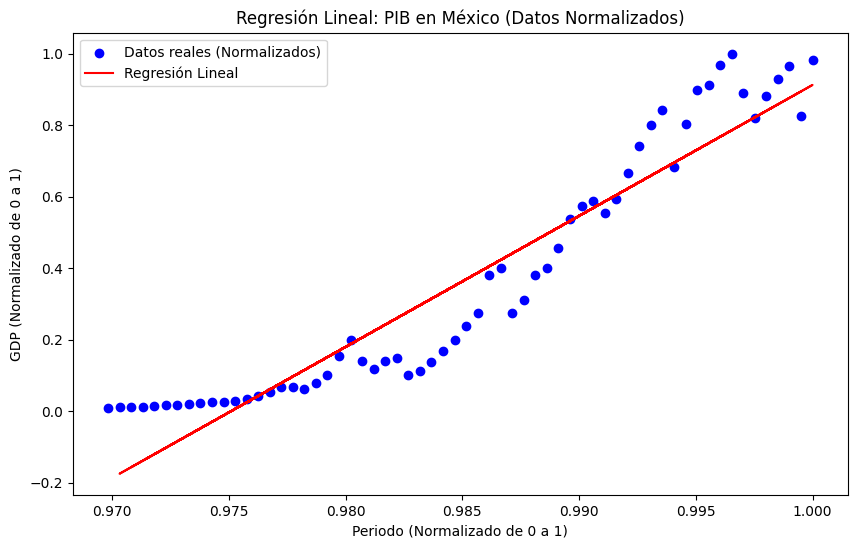

In [12]:
# 1. Cargamos la base de datos
os.chdir(r'C:\Users\Yamil\OneDrive\Escritorio\Escritorio\Yamil\EBAC (CIENCIA DE DATOS)\Bloque 4 Aprendizaje de máquina supervisado\MODULO 1 Regresión lineal simple\Práctica')
df_gdp = pd.read_excel('Mexico GDP.xlsx')

# 2. TRANSFORMACIÓN: Normalización dividiendo entre el valor máximo
df_norm = df_gdp.copy()
max_periodo = df_norm['Periodo'].max()
max_gdp = df_norm['GDP'].max()

# Dividimos cada columna entre su valor máximo
df_norm['Periodo'] = df_norm['Periodo'] / max_periodo
df_norm['GDP'] = df_norm['GDP'] / max_gdp

# 3. Definimos variables X y y normalizadas
X_norm = np.asanyarray(df_norm[['Periodo']])
y_norm = np.asanyarray(df_norm[['GDP']])

# 4. Dividimos los datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, test_size=0.20, random_state=42)

# 5. Entrenamos el modelo
regr = LinearRegression()
regr.fit(X_train, y_train)

# 6. Predicciones y Evaluación
y_hat = regr.predict(X_test)
print("--- Evaluación del Modelo Normalizado ---")
print("R2-score: %.4f" % r2_score(y_test, y_hat))

# 7. Pronóstico para 2022
# OJO: Como entrenamos con años normalizados, debemos normalizar el año 2022 para predecir
anio_2022_norm = np.array([[2022 / max_periodo]])
pronostico_2022_norm = regr.predict(anio_2022_norm)

# Para saber el valor en dinero real, lo multiplicamos de vuelta por el valor máximo del GDP
pronostico_2022_real = pronostico_2022_norm[0][0] * max_gdp
print(f"\nEl pronóstico del PIB para México en 2022 es: {pronostico_2022_real:,.2f}")

# 8. Gráfica Normalizada
plt.figure(figsize=(10, 6))
plt.scatter(X_norm, y_norm, color='blue', label='Datos reales (Normalizados)')
plt.plot(X_train, regr.coef_[0][0]*X_train + regr.intercept_[0], '-r', label='Regresión Lineal')
plt.xlabel("Periodo (Normalizado de 0 a 1)")
plt.ylabel("GDP (Normalizado de 0 a 1)")
plt.title("Regresión Lineal: PIB en México (Datos Normalizados)")
plt.legend()
plt.savefig('grafica_regresion_pib_normalizado.png', dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
plt.show()